#  Clustering with DBSCAN on the Iris Dataset

## Unsupervised Machine Learning Project

This notebook demonstrates how to apply the DBSCAN clustering algorithm on the Iris dataset.

The objectives are:

- Explore the dataset
- Standardize the features
- Determine a suitable value for epsilon (ε)
- Train a DBSCAN model
- Analyze the discovered clusters
- Visualize the results

Tools used:

- NumPy
- Pandas
- Matplotlib
- Scikit-Learn

In [3]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## Loading the Dataset

The Iris dataset is one of the most famous datasets in machine learning.

It contains measurements of 150 iris flowers:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Since DBSCAN is an unsupervised algorithm, the species labels will not be used during training.

In [4]:
iris = load_iris()

X = iris.data

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
print("Shape :", df.shape)

df.describe()

Shape : (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Feature Scaling

DBSCAN relies on distance calculations.

To ensure that all variables contribute equally, we standardize the features using StandardScaler.

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## Selecting Epsilon (ε)

A common method for choosing ε is the K-Distance Graph.

For each observation, we compute the distance to its k-th nearest neighbor.

The optimal ε is usually located near the "elbow" of the curve.

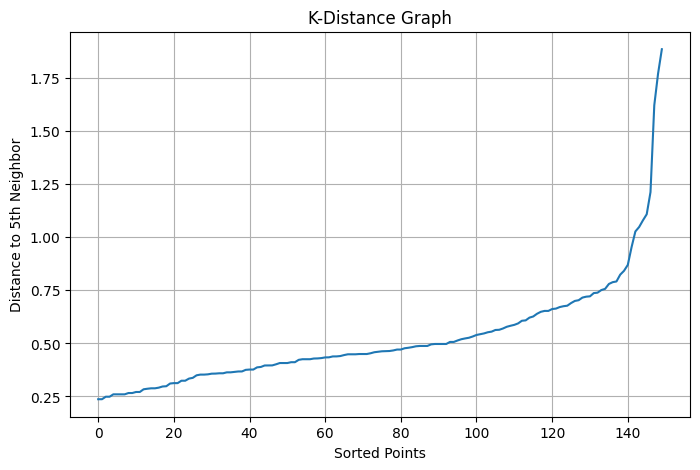

In [7]:
k = 5

neighbors = NearestNeighbors(
    n_neighbors=k
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(
    distances[:, k - 1]
)

plt.figure(figsize=(8,5))

plt.plot(distances)

plt.title("K-Distance Graph")
plt.xlabel("Sorted Points")
plt.ylabel("Distance to 5th Neighbor")

plt.grid(True)

plt.show()

## Training DBSCAN

After inspecting the K-Distance Graph, we choose an epsilon value and train the DBSCAN model.

In [8]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

labels[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Cluster Analysis

We examine:

- Number of clusters discovered
- Number of noise points
- Silhouette score

In [9]:
n_clusters = len(set(labels))

if -1 in labels:
    n_clusters -= 1

n_noise = np.sum(labels == -1)

print("Clusters found :", n_clusters)
print("Noise points :", n_noise)

if n_clusters > 1:
    score = silhouette_score(
        X_scaled,
        labels
    )

    print("Silhouette Score :", round(score, 3))

Clusters found : 2
Noise points : 4
Silhouette Score : 0.522


## PCA Visualization

Because the dataset contains four features, we reduce the dimensionality to two principal components for visualization.

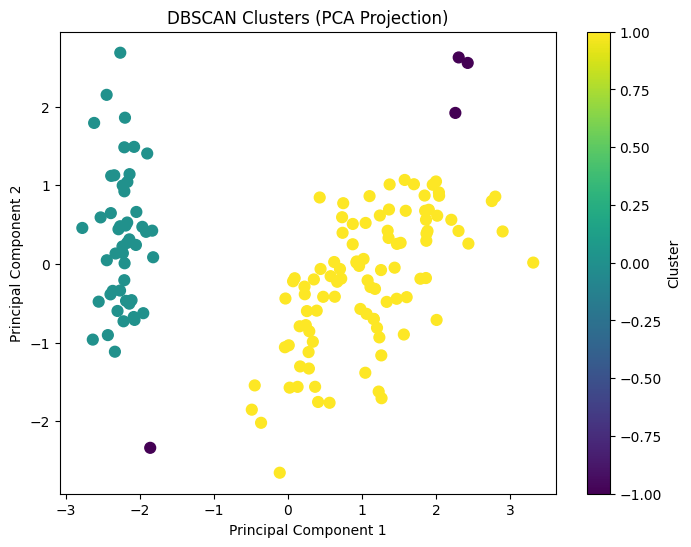

In [10]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap="viridis",
    s=60
)

plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(
    label="Cluster"
)

plt.show()

# Conclusion

In this project, we applied DBSCAN to the Iris dataset.

Key takeaways:

- DBSCAN identifies clusters based on density.
- It does not require specifying the number of clusters beforehand.
- It can naturally detect noise points.
- The quality of the results strongly depends on the choice of ε and min_samples.

Future improvements:

- Compare DBSCAN with K-Means.
- Compare DBSCAN with Hierarchical Clustering.
- Perform hyperparameter tuning.
- Test the algorithm on more complex datasets.